In [6]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# LOAD & CLEAN DATA
df = sns.load_dataset('titanic')

# Drop duplicates
df = df.drop_duplicates()

# Drop column with too many missing values
df = df.drop(columns=['deck'])

# Fill missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Cap extreme outliers in fare
fare_cap = df['fare'].quantile(0.95)
df['fare'] = np.where(df['fare'] > fare_cap, fare_cap, df['fare'])

print("Data is cleaned and ready for visualization!")

Data is cleaned and ready for visualization!


# 🚢 Titanic Data Cleaning & Visualization Project

**Objective:** Clean a raw dataset by handling missing values, outliers, and duplicates, then uncover insights through exploratory data analysis (EDA).

### Step 1: Environment Setup & Data Cleaning
Before visualizing, we need to prepare our data. In this phase, we will:
1. Load the Titanic dataset using Seaborn.
2. Remove duplicate rows.
3. Handle missing data (dropping columns with excessive missing values, and imputing medians/modes for others).
4. Cap extreme outliers in the ticket `fare` column using the 95th percentile to prevent them from skewing our visual distributions.

### Step 2: Univariate Analysis - Survival Rate by Class
**Question:** Did socioeconomic status (ticket class) impact the likelihood of survival?

We will use a **Bar Chart** to compare the average survival rate across 1st, 2nd, and 3rd-class passengers.

/tmp/ipykernel_1415/3110132967.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='class', y='survived', data=df, palette='muted', ci=None)
/tmp/ipykernel_1415/3110132967.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='survived', data=df, palette='muted', ci=None)


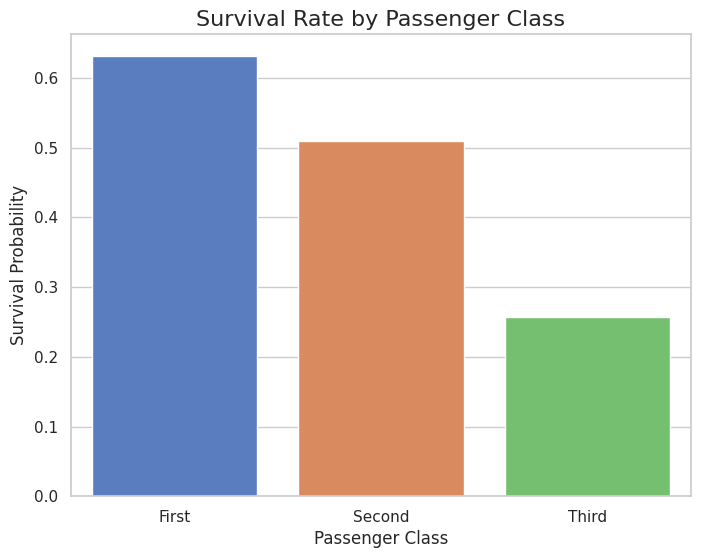

In [7]:
# GRAPH 1: BAR CHART
plt.figure(figsize=(8, 6))

# Create the bar plot
sns.barplot(x='class', y='survived', data=df, palette='muted', ci=None)

# Add titles and labels
plt.title('Survival Rate by Passenger Class', fontsize=16)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)

# Display the chart
plt.show()

### Step 3: Univariate Analysis - Age Distribution
**Question:** What was the general age demographic of the passengers on board?

We will use a **Histogram with a Kernel Density Estimate (KDE)** to visualize the distribution and spread of passenger ages.

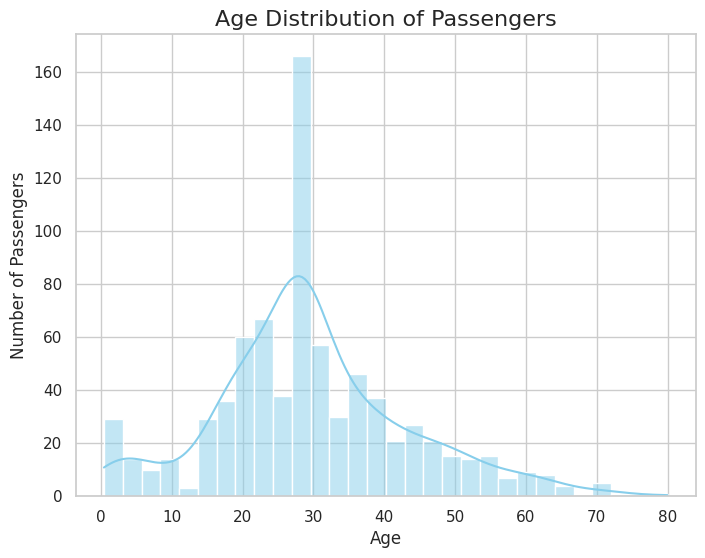

In [8]:
# GRAPH 2: HISTOGRAM
plt.figure(figsize=(8, 6))

# Create the histogram with a kernel density estimate (KDE) line
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')

# Add titles and labels
plt.title('Age Distribution of Passengers', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Display the chart
plt.show()

### Step 4: Multivariate Analysis - Fare vs. Age by Survival
**Question:** Is there a relationship between a passenger's age, how much they paid for their ticket, and whether they survived?

We will use a **Scatter Plot** to visualize Age on the X-axis and Ticket Fare on the Y-axis. We will color-code the data points based on survival status to spot any clustering or trends.

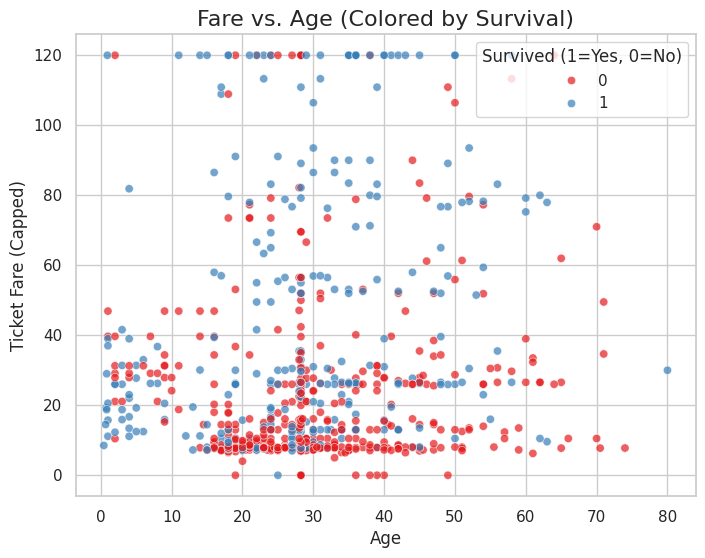

In [9]:
# GRAPH 3: SCATTER PLOT
plt.figure(figsize=(8, 6))

# Create the scatter plot
sns.scatterplot(x='age', y='fare', hue='survived', data=df, palette='Set1', alpha=0.7)

# Add titles and labels
plt.title('Fare vs. Age (Colored by Survival)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Ticket Fare (Capped)', fontsize=12)

# Adjust the legend
plt.legend(title='Survived (1=Yes, 0=No)')

# Display the chart
plt.show()